# Fault Tree Analysis (FTA)
## Security-Informed Safety Case Study with Extended Gates

This notebook implements a Fault Tree Analysis model for an industrial chemical plant.

# Introduction

This architecture presents a Fault Tree Analysis model for a 'chemical plant reactor overheating scenario'.  
It is based on a security-informed safety concept, meaning that it includes both cybersecurity causes and normal engineering failures in the same analysis.

The top event is 'reactor temperature exceeding the critical threshold'.  
To study this, the architecture connects cyber events, process failures, equipment faults, and human/operator issues through logical fault tree gates.  
This helps identify how different events individually or jointly can lead to the final unsafe condition.

### Features
- fault tree construction
- gate-by-gate probability analysis
- probability tables
- MOCUS cut-set analysis
- MICSUP minimal cut-set analysis
- standard-like FTA visualization
- gates beyond AND and OR:
  - AND
  - OR
  - XOR
  - PAND
  - INHIBIT

## 1. Import Required Libraries

In this section, all required libraries are imported for:
- data structures
- probability calculations
- table generation
- graph generation
- image display in Jupyter

In [5]:
from __future__ import annotations

from dataclasses import dataclass, field
from itertools import product
from typing import Dict, List, Optional, Set, Tuple
import os
import tempfile

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, PathPatch
from matplotlib.path import Path
from graphviz import Digraph
from IPython.display import Image, display

## 2. Create Standard-Like Gate Icons

Graphviz does not directly provide textbook FTA gate symbols, so custom gate icons are generated automatically.

Supported gates:
- AND
- OR
- XOR
- PAND
- INHIBIT

In [6]:
def create_gate_icons(output_dir: str) -> Dict[str, str]:
    """
    Generate all the custom PNG icons we need for the fault tree.
    Saves them to the output_dir and returns a mapping for the visualizer.
    """
    # Just a safety check to make sure the folder exists before we try saving files
    os.makedirs(output_dir, exist_ok=True)

    # Dictionary to keep track of where each icon lives on the disk
    paths = {
        "AND": os.path.join(output_dir, "and_gate.png"),
        "OR": os.path.join(output_dir, "or_gate.png"),
        "XOR": os.path.join(output_dir, "xor_gate.png"),
        "PAND": os.path.join(output_dir, "pand_gate.png"),
        "INHIBIT": os.path.join(output_dir, "inhibit_gate.png"),
    }

    # DRAWING THE AND GATE
    # We want that classic "D" shape. Subplots help us keep the canvas consistent.
    fig, ax = plt.subplots(figsize=(2, 1.4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off") # Get rid of the XY axis; we just want the shape

    # The top of the AND gate is a semi-circle (Wedge)
    wedge = Wedge(
        (0.5, 0.35),
        r=0.35,
        theta1=0,
        theta2=180,
        facecolor="#4F81BD", # Keeping the standard blue theme
        edgecolor="black",
        linewidth=1.2
    )
    ax.add_patch(wedge)
    # Close the bottom of the "D" with a flat line
    ax.plot([0.15, 0.85], [0.35, 0.35], color="black", linewidth=1.2)
    # High DPI makes sure the icon doesn't look blurry in the final Graphviz export
    plt.savefig(paths["AND"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # DRAWING THE OR GATE
    fig, ax = plt.subplots(figsize=(2, 1.6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # OR gates are tricky because they're curvy. Using a Path with CURVE3 for that "pointy" look.
    verts = [
        (0.15, 0.62), (0.50, 0.92), (0.85, 0.62), # The pointed top
        (0.78, 0.36), (0.50, 0.10), (0.22, 0.36), # The curved bottom
        (0.15, 0.62), # Close the loop
    ]
    codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3, Path.CURVE3, Path.CURVE3, Path.CURVE3, Path.CURVE3]
    patch = PathPatch(Path(verts, codes), facecolor="#4F81BD", edgecolor="black", linewidth=1.2)
    ax.add_patch(patch)
    # Added a small horizontal line to anchor it visually
    ax.plot([0.18, 0.82], [0.62, 0.62], color="black", linewidth=1.2)
    plt.savefig(paths["OR"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # DRAWING THE XOR GATE
    fig, ax = plt.subplots(figsize=(2, 1.7))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Reuse the OR shape but color it purple to distinguish it
    patch = PathPatch(Path(verts, codes), facecolor="#8E7CC3", edgecolor="black", linewidth=1.2)
    ax.add_patch(patch)
    ax.plot([0.18, 0.82], [0.62, 0.62], color="black", linewidth=1.2)

    # XOR gates need that extra curved line at the bottom
    extra_verts = [(0.10, 0.60), (0.17, 0.36), (0.40, 0.12)]
    extra_codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3]
    extra_patch = PathPatch(Path(extra_verts, extra_codes), facecolor="none", edgecolor="black", linewidth=1.0)
    ax.add_patch(extra_patch)

    # Stick an 'X' in the middle so there's zero confusion
    ax.text(0.5, 0.62, "X", ha="center", va="center", fontsize=12, color="white", weight="bold")
    plt.savefig(paths["XOR"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # DRAWING THE PAND (PRIORITY AND) GATE
    fig, ax = plt.subplots(figsize=(2, 1.4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # PAND looks like an AND gate but usually orange to signal "Warning: Sequence Matters"
    wedge = Wedge(
        (0.5, 0.35), r=0.35, theta1=0, theta2=180,
        facecolor="#F6B26B", edgecolor="black", linewidth=1.2
    )
    ax.add_patch(wedge)
    ax.plot([0.15, 0.85], [0.35, 0.35], color="black", linewidth=1.2)
    # Add a 'P' for Priority
    ax.text(0.5, 0.18, "P", ha="center", va="center", fontsize=12, color="black", weight="bold")
    plt.savefig(paths["PAND"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # --- DRAWING THE INHIBIT GATE ---
    fig, ax = plt.subplots(figsize=(1.6, 1.6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Inhibit gates are traditionally hexagons. Defined the vertices manually here.
    inhibit_shape = plt.Polygon(
        [[0.50, 0.90], [0.82, 0.68], [0.82, 0.32], [0.50, 0.10], [0.18, 0.32], [0.18, 0.68]],
        closed=True,
        facecolor="#93C47D", # Green signifies a "condition" that must be met
        edgecolor="black",
        linewidth=1.2
    )
    ax.add_patch(inhibit_shape)
    # Label it 'I' for Inhibit
    ax.text(0.5, 0.5, "I", ha="center", va="center", fontsize=12, color="black", weight="bold")
    plt.savefig(paths["INHIBIT"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # Pass the full set of image paths back to the main FTA engine
    return paths

## 3. Define the Fault Tree Node Structure

The **Fault Tree Node** is the fundamental building block of the model, representing either a **Basic Event** or a **Logic Gate**.

* **Basic Events:** Leaf nodes with a fixed probability (0.0 to 1.0).
* **Logic Gates:** Intermediate nodes that calculate probability from their children.
* **Validation:** Ensures gates have inputs, basic events don't, and specific gates (like **INHIBIT**) have the correct number of children.

**Supported Types:**
* **AND / OR:** Standard parallel/series logic.
* **XOR:** Exactly one input fails.
* **PAND:** Inputs must fail in a specific sequence.
* **INHIBIT:** Event only fails if a specific condition is met.

In [7]:
@dataclass
class FaultTreeNode:

    name: str # The human-readable label for the event or gate
    node_type: str # Tells the engine which math logic to apply
    probability: Optional[float] = None # Only used for BASIC events
    children: List["FaultTreeNode"] = field(default_factory=list) # Holds the inputs for a gate

    def is_basic(self) -> bool:
        """Quick helper to check if this is a leaf node (a basic event)."""
        return self.node_type == "BASIC"

    def validate(self) -> None:

        # Define the 'legal' gate types we've implemented in the engine
        valid_types = {"BASIC", "AND", "OR", "XOR", "PAND", "INHIBIT"}

        # First, make sure the user didn't provide a node type we don't recognize
        if self.node_type not in valid_types:
            raise ValueError(f"Invalid node type '{self.node_type}' in node '{self.name}'.")

        # Rules for BASIC (leaf) events:
        if self.is_basic():
            # A basic event is useless without a starting probability
            if self.probability is None:
                raise ValueError(f"Basic event '{self.name}' must have a probability.")

            # Probability must stay within the logical bounds of 0% to 100%
            if not (0.0 <= self.probability <= 1.0):
                raise ValueError(f"Probability of '{self.name}' must be between 0 and 1.")

            # Basic events represent the 'end' of a branch; they shouldn't have inputs
            if self.children:
                raise ValueError(f"Basic event '{self.name}' cannot have children.")

        # Rules for GATE nodes:
        else:
            # Gates calculate their own probability from children, so don't manually set one
            if self.probability is not None:
                raise ValueError(f"Gate node '{self.name}' must not have a direct probability.")

            # Every gate needs at least one input to function
            if not self.children:
                raise ValueError(f"Gate node '{self.name}' must have at least one child.")

            # INHIBIT gates specifically require 2 inputs: the Event and the Condition
            if self.node_type == "INHIBIT" and len(self.children) != 2:
                raise ValueError(f"INHIBIT gate '{self.name}' must have exactly 2 children.")

            # PAND needs at least two events to establish a 'priority' sequence
            if self.node_type == "PAND" and len(self.children) < 2:
                raise ValueError(f"PAND gate '{self.name}' must have at least 2 children.")

            # XOR requires a choice between at least two mutually exclusive events
            if self.node_type == "XOR" and len(self.children) < 2:
                raise ValueError(f"XOR gate '{self.name}' must have at least 2 children.")

## 4. Utility Functions

These helper functions are used for:
- gate probability calculations
- cut-set minimization
- formatting labels
- clean probability display
- identifying security-related events

## Gate Probability Calculations ##

### 1. AND Gate

**Meaning:**  
The output event occurs only if all input events occur simultaneously.

**Formula**:  
P(AND) = P1 × P2 × ... × Pn  

**Example**:  
If A = 0.2 and B = 0.3  
P(A AND B) = 0.2 × 0.3 = 0.06  


In [8]:
def and_gate_probability(probabilities: List[float]) -> float:

    result = 1.0
    for p in probabilities:
        result *= p # If any p is 0, the whole thing becomes 0
    return result


##2. OR Gate

**Meaning:**  
The output event occurs if at least one input event occurs.

**Formula:**  
P(OR) = 1 − [(1−P1)(1−P2)...(1−Pn)]  

**Example:**  
If A = 0.2 and B = 0.3  
P(A OR B) = 1 − (0.8 × 0.7) = 0.44  


In [9]:
def or_gate_probability(probabilities: List[float]) -> float:

    result = 1.0
    for p in probabilities:
        result *= (1.0 - p) # Multiply the chances of each event NOT happening
    return 1.0 - result


## 3. XOR Gate (Exclusive OR)

**Meaning:**  
The output occurs if exactly one input occurs.

**Formula (2 inputs):**  
P = P1(1 − P2) + P2(1 − P1)  

**Example:**  
A = 0.2, B = 0.3  
P = 0.2×0.7 + 0.3×0.8 = 0.38  


In [10]:
def xor_gate_probability(probabilities: List[float]) -> float:

    total = 0.0
    for i, p in enumerate(probabilities):
        # Start with the probability of the current event 'i'
        term = p
        # Multiply by the probability that every OTHER event 'j' does NOT happen
        for j, q in enumerate(probabilities):
            if i != j:
                term *= (1.0 - q)
        # Sum up these individual 'exactly one' scenarios
        total += term
    return total



### 4. PAND Gate (Priority AND)

**Meaning:**  
All events must occur in a specific order.

**In this implementation:**  
P(PAND) ≈ P1 × P2 × ... × Pn  

Note: True PAND requires time-based modeling.  



In [11]:
def pand_gate_probability(probabilities: List[float]) -> float:
    """
    Priority AND logic usually depends on the sequence of time.
    Since we aren't modeling timestamps here, we treat it as a
    standard AND gate for the static calculation.
    """
    return and_gate_probability(probabilities)


### 5. INHIBIT Gate

**Meaning:**  
The event occurs only if a conditioning event is satisfied.

**Formula:**  
P = P(main event) × P(condition)  

**Example:**  
Failure = 0.3, Condition = 0.5  
P = 0.3 × 0.5 = 0.15  

In [12]:
def inhibit_gate_probability(probabilities: List[float]) -> float:
    """
    The INHIBIT gate is basically an AND gate with a 'gatekeeper' condition.
    It expects the main failure event (0) and the conditional event (1).
    """
    # Double check we have exactly two inputs as required by the node validator
    if len(probabilities) != 2:
        raise ValueError("INHIBIT gate requires exactly 2 child probabilities.")

    # Just a simple product: failure only occurs if both the event and condition align
    return probabilities[0] * probabilities[1]

### **Cut Set Minimization**

**Minimization** filters out redundant failure paths to find the **Minimal Cut Sets (MCS)**.

* **The Rule:** If a small set (e.g., `{A}`) causes failure, any larger set containing it (e.g., `{A, B}`) is **redundant** and removed.
* **The Logic:** If the system fails when "A" happens, "B" is just "extra" info—the shortest path to failure is just "A".
* **The Goal:** To isolate **Single Point Failures** and prevent the inflation of probability math.

In [13]:
def minimize_cut_sets(cut_sets: List[Set[str]]) -> List[Set[str]]:

    # Use frozenset so we can put them in a 'set' to instantly kill duplicate paths
    unique_sets = list({frozenset(cs) for cs in cut_sets})

    # Sort by length first; we want to compare the smallest sets against the bigger ones
    unique_sets.sort(key=lambda s: (len(s), sorted(s)))

    minimal: List[frozenset] = []
    for candidate in unique_sets:
        is_superset = False
        # Check if any smaller set we already kept is actually inside this new 'candidate'
        for kept in minimal:
            if kept.issubset(candidate):
                is_superset = True # If we found a subset, this candidate is redundant
                break

        # Only keep the path if it's truly a unique, minimal combination
        if not is_superset:
            minimal.append(candidate)

    # Convert back to standard sets for the rest of the program to use
    return [set(x) for x in minimal]


def wrap_text(text: str, max_len: int = 22, max_lines: int = 4) -> str:
    """
    Graphviz is terrible at handling long strings in boxes.
    This helper chops long event names into multiple lines so the diagram stays readable.
    """
    words = text.split()
    lines = []
    current = ""

    for word in words:
        # Build the line word by word until it hits our length limit
        candidate = f"{current} {word}".strip()
        if len(candidate) <= max_len:
            current = candidate
        else:
            # Current line is full, push it and start the next line with the current word
            if current:
                lines.append(current)
            current = word

    # Don't forget to grab the very last word/line
    if current:
        lines.append(current)

    # If the name is ridiculously long, truncate it with '...' so it doesn't break the UI
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1][:max(0, max_len - 3)] + "..."

    # Return as a single string with newlines for the Graphviz label
    return "\n".join(lines)

## Formatting labels and Identifying Security related events ##

In [14]:
def format_prob(p: float, decimals: int = 3) -> str:
    # Round probability to given decimals and remove trailing zeros
    return f"{round(p, decimals):g}"


def is_security_event(name: str) -> bool:
    # Keywords representing cybersecurity-related events
    keywords = [
        "intrusion", "attacker", "spoofed", "dos", "alarm",
        "vpn", "historian", "malicious", "credential",
        "workstation", "hmi", "interlock", "remote access",
        "firewall", "segmentation", "logic"
    ]

    lower_name = name.lower()  # case-insensitive matching

    # Return True if any security keyword is found in event name
    return any(k in lower_name for k in keywords)

## 5. Build the Main Fault Tree Class

This class controls:
- validation
- probability evaluation
- result tables
- MOCUS
- MICSUP
- standard-like FTA visualization

## Validation and Traversal

This section ensures that the fault tree is correctly structured before performing any analysis.

**Validation** checks:
- Each node has a valid type (BASIC, AND, OR, XOR, PAND, INHIBIT)
- Basic events have assigned probabilities (0 to 1)
- Gate nodes have appropriate child nodes
- Special rules (e.g., INHIBIT must have exactly 2 children)

**Traversal** is done using Depth-First Search (DFS) to:
- Visit every node in the fault tree
- Validate all nodes recursively
- Build internal structures like node lists and lookup tables

This step guarantees that the fault tree is logically consistent and ready for probability and cut-set analysis.

In [15]:
class FaultTree:

    def __init__(self, root: FaultTreeNode, title: str = "Fault Tree") -> None:
        """
        Initializes the fault tree with a root node and title.
        Also performs validation to ensure correct structure.
        """
        self.root = root              # Top event of the fault tree
        self.title = title            # Title of the analysis
        self._validate_tree()         # Validate entire tree on creation

    def _validate_tree(self) -> None:
        """
        Traverses the tree using DFS and validates each node.
        Prevents infinite loops using a visited set.
        """
        visited = set()               # Track visited nodes to avoid cycles

        def dfs(node: FaultTreeNode) -> None:
            if id(node) in visited:   # Skip if already visited
                return
            visited.add(id(node))     # Mark node as visited
            node.validate()           # Validate node rules (type, children, probability)

            for child in node.children:
                dfs(child)            # Recursively visit child nodes

        dfs(self.root)                # Start traversal from root node

    def _collect_nodes(self) -> List[FaultTreeNode]:
        """Returns all nodes in the tree as a list."""
        nodes: List[FaultTreeNode] = []

        def dfs(node: FaultTreeNode) -> None:
            nodes.append(node)        # Add current node to list
            for child in node.children:
                dfs(child)            # Visit all children

        dfs(self.root)
        return nodes                  # Flattened list of all nodes

    def build_lookup(self) -> Dict[str, FaultTreeNode]:
        """Creates a dictionary for fast node access using names."""
        lookup: Dict[str, FaultTreeNode] = {}

        def dfs(node: FaultTreeNode) -> None:
            lookup[node.name] = node  # Map node name → node object
            for child in node.children:
                dfs(child)            # Traverse all children

        dfs(self.root)
        return lookup                 # Return lookup dictionary

## Probability Analysis

This section computes the probability of the top event based on all basic events.

- Uses **recursive Depth-First Search (DFS)** to evaluate the tree
- Basic events return their assigned probabilities
- Gate nodes compute output using logical probability rules:
  - AND → product of probabilities  
  - OR → union probability  
  - XOR → exactly one event occurs  
  - PAND → approximated as AND  
  - INHIBIT → conditional AND  

The result is:
- Probability of every node
- Final probability of the **top event**

In [16]:
def evaluate_probabilities(self, verbose: bool = False) -> Tuple[float, Dict[str, float]]:
    results: Dict[str, float] = {}   # Stores probability of each node

    def evaluate(node: FaultTreeNode) -> float:

        if node.is_basic():
            results[node.name] = node.probability   # Basic event → direct probability
            if verbose:
                print(f"[BASIC] {node.name}")
                print(f"        P = {format_prob(node.probability)}")
            return node.probability

        # Recursively evaluate all child nodes
        child_probabilities = [evaluate(child) for child in node.children]

        # Apply gate logic based on type
        if node.node_type == "AND":
            value = and_gate_probability(child_probabilities)
        elif node.node_type == "OR":
            value = or_gate_probability(child_probabilities)
        elif node.node_type == "XOR":
            value = xor_gate_probability(child_probabilities)
        elif node.node_type == "PAND":
            value = pand_gate_probability(child_probabilities)
        elif node.node_type == "INHIBIT":
            value = inhibit_gate_probability(child_probabilities)
        else:
            raise ValueError(f"Unknown node type: {node.node_type}")

        results[node.name] = value   # Store computed gate probability

        if verbose:
            print(f"[{node.node_type}] {node.name}")
            for child, prob in zip(node.children, child_probabilities):
                print(f"        Child: {child.name} -> {format_prob(prob)}")
            print(f"        Result: P({node.name}) = {format_prob(value)}")

        return value

    top_probability = evaluate(self.root)   # Start evaluation from top event
    return top_probability, results         # Return top event + all node probabilities
def probability_table(self) -> pd.DataFrame:
    _, probabilities = self.evaluate_probabilities(verbose=False)  # Compute all probabilities
    rows = []

    for node in self._collect_nodes():
        rows.append({
            "Node": node.name,                      # Node name
            "Type": node.node_type,                # Gate or BASIC
            "Probability": format_prob(probabilities[node.name])  # Formatted probability
        })

    df = pd.DataFrame(rows)

    # Define order for sorting types
    type_order = {"BASIC": 0, "AND": 1, "OR": 2, "XOR": 3, "PAND": 4, "INHIBIT": 5}
    df["SortKey"] = df["Type"].map(type_order)

    # Sort table by type and name
    df = df.sort_values(["SortKey", "Node"]).drop(columns=["SortKey"]).reset_index(drop=True)
    return df
def gate_analysis_table(self) -> pd.DataFrame:
    _, probabilities = self.evaluate_probabilities(verbose=False)  # Get all node probabilities
    rows = []

    def dfs(node: FaultTreeNode) -> None:
        if not node.is_basic():   # Process only gate nodes

            child_names = [child.name for child in node.children]   # Child names
            child_probs = [probabilities[child.name] for child in node.children]  # Child probabilities

            rows.append({
                "Gate": node.name,                       # Gate name
                "Gate Type": node.node_type,             # Gate type (AND, OR, etc.)
                "Children": " | ".join(child_names),     # List of children
                "Child Probabilities": " | ".join(format_prob(p) for p in child_probs),
                "Gate Probability": format_prob(probabilities[node.name])  # Final gate output
            })

        for child in node.children:
            dfs(child)   # Traverse all nodes

    dfs(self.root)
    return pd.DataFrame(rows)


## MOCUS (Method for Obtaining Cut Sets)  ##

MOCUS is an algorithm that identifies the Minimal Cut Sets (MCS)—the smallest combinations of basic events that trigger a system failure.

*   AND: Replaces the gate in the same row with all its inputs (increases cut set size).
*   OR: Replaces the gate by creating new rows for each input (increases the number of cut sets).

* XOR: Treated like an OR gate, but with a constraint that only one input occurs. In standard MOCUS, it creates new rows for each input.

* PAND (Priority AND): Treated like an AND gate (inputs added to the same row), but often tagged with a "sequence" marker to show Order matters.

*  INHIBIT: Treated like an AND gate between the input event and the conditioning (inhibitor) event.








In [13]:
    def mocus(self) -> Tuple[List[Set[str]], List[Set[str]]]:

        # Grab the map of names to actual nodes so we can look them up quickly
        lookup = self.build_lookup()
        # We start with a single 'row' containing just the Top Event name
        rows: List[List[str]] = [[self.root.name]]

        # We keep looping as long as we find a gate that still needs to be broken down
        changed = True
        while changed:
            changed = False
            new_rows: List[List[str]] = []

            for row in rows:
                expanded = False

                # Scan the current row for any item that is a gate, not a basic event
                for index, event_name in enumerate(row):
                    node = lookup[event_name]

                    # If it's a basic event, keep moving; nothing to expand here
                    if node.is_basic():
                        continue

                    # We found a gate! Mark that we're making a change in this pass
                    expanded = True
                    changed = True

                    # OR and XOR logic: These create entirely new ways to fail.
                    # We duplicate the current row for every child the gate has.
                    if node.node_type in {"OR", "XOR"}:
                        for child in node.children:
                            # Add a new row where the gate is replaced by just one child
                            new_rows.append(row[:index] + [child.name] + row[index + 1:])

                    # AND, PAND, and INHIBIT logic: These require multiple things to happen.
                    # We replace the gate in the CURRENT row with all its children horizontally.
                    elif node.node_type in {"AND", "PAND", "INHIBIT"}:
                        child_names = [child.name for child in node.children]
                        # This row gets 'wider' because more events must coincide
                        new_rows.append(row[:index] + child_names + row[index + 1:])

                    else:
                        # Safety check in case a new node type was added but not handled here
                        raise ValueError(f"Unknown node type in MOCUS: {node.node_type}")

                    # Once we expand one gate in a row, we move to the next row to keep it stable
                    break

                # If a row was already all basic events, just carry it over to the next pass
                if not expanded:
                    new_rows.append(row)

            # Update our master list with the newly expanded rows
            rows = new_rows

        # Convert the final list of strings into actual sets for the final output
        all_cut_sets = [set(row) for row in rows]
        # Run our minimization filter to remove redundant or non-minimal paths
        minimal_cut_sets = minimize_cut_sets(all_cut_sets)

        return all_cut_sets, minimal_cut_sets


##MICSUP (Minimal Cut Set Upward) ##

MICSUP is a bottom-up algorithm used to identify Minimal Cut Sets (MCS). Unlike MOCUS, which starts at the top and drills down, MICSUP starts at the leaves (basic events) and works its way up the tree.

*   AND: Performs a Cartesian Product of the child sets (e.g., $\{A\} \times \{B\} = \{A, B\}$).

*   OR: Performs a Union of all child sets (e.g., $\{A\} \cup \{B\} = \{A\}, \{B\}$).

*   XOR: Performs a Union (similar to OR) but usually filters out cases where both events occur during probability calculation.

*  PAND: Performs a Cartesian Product (like AND), but the resulting set is mathematically weighted to account for the required sequence.

* INHIBIT: Performs a Cartesian Product between the failure event and the active condition set.

In [14]:
    def micsup(self) -> List[Set[str]]:
        """
        This is our bottom-up alternative to MOCUS. It starts at the leaves
        and works its way up, combining sets according to Boolean rules.
        """
        def compute(node: FaultTreeNode) -> List[Set[str]]:
            # Base case: If we're at a basic event, it's a cut set of size one
            if node.is_basic():
                return [{node.name}]

            # Recursive step: Go down and get the cut sets for all children first
            child_cut_sets = [compute(child) for child in node.children]

            # OR and XOR logic: These are 'Unions'. We just take all the failure
            # paths from every child and throw them into one big list.
            if node.node_type in {"OR", "XOR"}:
                combined: List[Set[str]] = []
                for csets in child_cut_sets:
                    combined.extend(csets)
                # Clean up the list immediately to keep the memory usage low
                return minimize_cut_sets(combined)

            # AND, PAND, and INHIBIT logic: These are 'Cartesian Products'.
            # To fail an AND gate, we need one path from EVERY child to occur together.
            if node.node_type in {"AND", "PAND", "INHIBIT"}:
                combined: List[Set[str]] = []
                # Use itertools.product to get every possible combination across children
                for combo in product(*child_cut_sets):
                    merged: Set[str] = set()
                    for cs in combo:
                        merged |= cs # Merge all events in this combination into one set
                    combined.append(merged)
                return minimize_cut_sets(combined)

            raise ValueError(f"Unknown node type in MICSUP: {node.node_type}")

        # Start the recursive engine at the top of the tree
        return compute(self.root)

    def cut_set_table(self, cut_sets: List[Set[str]]) -> pd.DataFrame:
        """
        Takes the raw sets of strings and turns them into a pretty Pandas table.
        This is what we actually show in the Jupyter notebook.
        """
        rows = []
        for idx, cut_set in enumerate(cut_sets, start=1):
            rows.append({
                "ID": idx,
                "Cut Set": ", ".join(sorted(cut_set)), # Sort names alphabetically for readability
                "Order": len(cut_set) # 'Order' is just how many events are in the set
            })

        # Corner case: if the tree is perfectly safe (impossible, but good to handle)
        if not rows:
            return pd.DataFrame(columns=["ID", "Cut Set", "Order"])

        df = pd.DataFrame(rows)
        # Sort by Order (smallest sets first) and then by name so the table is predictable
        df = df.sort_values(["Order", "Cut Set"]).reset_index(drop=True)
        return df

## Visualization

This section generates the graphical Fault Tree diagram for the system.

- Basic events are shown as labeled event boxes with probability values
- Gate nodes are shown using their corresponding gate symbols
- Security-related basic events are highlighted with a different color
- The tree is drawn from the **top event downward** to show cause-to-effect structure clearly

This visualization makes the fault tree easier to understand and helps in presenting the relationship between events and logic gates.

In [15]:
def visualize_standard_fta(self, save_path: Optional[str] = None) -> str:
    output_name = save_path if save_path else "extended_fault_tree"  # output file name

    temp_dir = tempfile.mkdtemp(prefix="fta_icons_")
    gate_icons = create_gate_icons(temp_dir)  # create gate symbol images

    dot = Digraph("FaultTree", format="png")
    dot.attr(rankdir="TB", splines="ortho", nodesep="0.55", ranksep="0.85")  # top-down layout
    dot.attr(fontname="Helvetica")
    dot.attr("edge", fontname="Helvetica", fontsize="8")

    node_ids: Dict[str, str] = {}
    counter = 0

    def get_node_id(node_name: str) -> str:
        nonlocal counter
        if node_name not in node_ids:
            node_ids[node_name] = f"n{counter}"  # unique id for each node
            counter += 1
        return node_ids[node_name]

    def add_node_recursive(node: FaultTreeNode) -> str:
        base_id = get_node_id(node.name)

        # BASIC event
        if node.node_type == "BASIC":
            event_id = f"{base_id}_event"
            symbol_id = f"{base_id}_symbol"
            prob_id = f"{base_id}_prob"

            dot.node(
                event_id,
                label=wrap_text(node.name),   # event name
                shape="box",
                style="rounded,filled",
                fillcolor="white",
                color="black",
                width="1.9",
                height="0.75"
            )

            basic_fill = "#C0504D" if is_security_event(node.name) else "#5B9BD5"
            dot.node(
                symbol_id,
                label="",
                shape="circle",
                style="filled",
                fillcolor=basic_fill,   # highlight security-related events differently
                color="black",
                width="0.32",
                height="0.32",
                fixedsize="true"
            )

            dot.node(
                prob_id,
                label=f"P = {format_prob(node.probability)}",  # show basic event probability
                shape="box",
                style="filled",
                fillcolor="white",
                color="black",
                width="1.2",
                height="0.25",
                fontsize="8"
            )

            dot.edge(event_id, symbol_id, arrowhead="none")
            dot.edge(symbol_id, prob_id, arrowhead="none")
            return event_id

        # GATE node
        event_id = f"{base_id}_event"
        gate_id = f"{base_id}_gate"

        dot.node(
            event_id,
            label=wrap_text(node.name),   # gate output label
            shape="box",
            style="rounded,filled",
            fillcolor="white",
            color="black",
            width="2.0",
            height="0.75"
        )

        gate_image = gate_icons[node.node_type]

        dot.node(
            gate_id,
            label=node.node_type,
            labelloc="b",
            shape="none",
            image=gate_image,   # use gate icon image
            imagescale="true",
            width="0.95",
            height="0.55",
            fixedsize="true",
            fontsize="9"
        )

        dot.edge(event_id, gate_id, arrowhead="none")

        for child in node.children:
            child_anchor = add_node_recursive(child)  # recursively add child nodes
            dot.edge(gate_id, child_anchor, arrowhead="none")

        return event_id

    add_node_recursive(self.root)  # start building from root node

    png_path = dot.render(output_name, cleanup=True)  # generate PNG file

    if os.path.exists(png_path):
        display(Image(filename=png_path))  # display image in notebook
    else:
        print("Could not find generated image. Please check Graphviz installation.")

    print(f"Diagram saved as: {png_path}")
    return png_path


# DASHBOARD
def run_dashboard(self, image_path: Optional[str] = None) -> Dict[str, pd.DataFrame]:
    top_probability, _ = self.evaluate_probabilities(verbose=False)  # compute top event probability

    print("=" * 100)
    print(self.title.upper())   # display title
    print("=" * 100)
    print()
    print(f"Top Event Probability: {format_prob(top_probability)}")  # print final probability
    print()

    self.visualize_standard_fta(save_path=image_path)  # generate and show fault tree diagram

    probability_df = self.probability_table()      # table of all node probabilities
    gate_df = self.gate_analysis_table()           # gate-wise probability breakdown

    all_cut_sets_mocus, minimal_mocus = self.mocus()   # MOCUS cut sets
    minimal_micsup = self.micsup()                     # MICSUP cut sets

    mocus_all_df = self.cut_set_table(all_cut_sets_mocus)
    mocus_min_df = self.cut_set_table(minimal_mocus)
    micsup_min_df = self.cut_set_table(minimal_micsup)

    mocus_sorted = sorted(tuple(sorted(cs)) for cs in minimal_mocus)
    micsup_sorted = sorted(tuple(sorted(cs)) for cs in minimal_micsup)

    print("MOCUS and MICSUP match:", mocus_sorted == micsup_sorted)  # verify both methods agree

    return {
        "probability_table": probability_df,
        "gate_analysis_table": gate_df,
        "mocus_all_cut_sets": mocus_all_df,
        "mocus_minimal_cut_sets": mocus_min_df,
        "micsup_minimal_cut_sets": micsup_min_df,
    }

## Chemical Plant Case Study

This case study models a realistic industrial chemical plant by integrating multiple types of failures into a single fault tree.

It combines:

- **Cybersecurity events**  
  Such as unauthorized access, malware attacks, VPN misuse, and PLC logic manipulation, which can disrupt control systems.

- **Physical / process failures**  
  Includes equipment failures like cooling pump faults, heat exchanger fouling, and sensor drift that directly affect plant operation.

- **Operator-related events**  
  Human factors such as delayed response or incorrect actions that can worsen abnormal conditions.

- **Advanced logical gates**  
  Uses AND, OR, XOR, PAND, and INHIBIT gates to model complex interactions between events.

This integrated approach helps analyze how cyber threats and physical failures together can lead to critical incidents such as reactor temperature exceeding safe limits.

In [16]:
def build_complex_chemical_plant_case() -> FaultTree:

    # BASIC EVENTS (leaf nodes with probabilities)


    # Cybersecurity-related events
    weak_remote_access_control = FaultTreeNode("Weak remote access control", "BASIC", 0.02)
    stolen_credentials = FaultTreeNode("Stolen operator or vendor credentials", "BASIC", 0.018)
    vpn_misuse = FaultTreeNode("Unauthorized remote access via VPN misuse", "BASIC", 0.012)
    firewall_segmentation_failure = FaultTreeNode("Firewall or network segmentation failure", "BASIC", 0.015)
    ics_network_intrusion = FaultTreeNode("ICS network intrusion", "BASIC", 0.03)

    # Control system compromise
    engineering_workstation_compromise = FaultTreeNode("Engineering workstation compromise", "BASIC", 0.018)
    setpoint_modification = FaultTreeNode("Setpoint modified by attacker", "BASIC", 0.025)
    malicious_plc_logic = FaultTreeNode("Malicious PLC logic modification", "BASIC", 0.015)
    safety_interlock_bypass = FaultTreeNode("Safety interlock bypass attempt", "BASIC", 0.008)

    # Monitoring & visibility issues
    spoofed_temp_sensor = FaultTreeNode("Spoofed temperature sensor reads low", "BASIC", 0.02)
    historian_tampering = FaultTreeNode("Historian or HMI data tampering", "BASIC", 0.01)
    alarm_suppression = FaultTreeNode("Alarm or HMI suppression by attacker", "BASIC", 0.01)

    # Denial-of-service
    dos_cooling_controller = FaultTreeNode("DoS on cooling system controller", "BASIC", 0.015)

    # Physical/process failures
    feed_composition_upset = FaultTreeNode("Feed composition upset increases heat release", "BASIC", 0.04)
    reactor_agitation_degradation = FaultTreeNode("Reactor agitation degradation", "BASIC", 0.02)
    cooling_pump_failure = FaultTreeNode("Cooling pump mechanical failure", "BASIC", 0.05)
    heat_exchanger_fouling = FaultTreeNode("Heat exchanger fouling reduces cooling", "BASIC", 0.04)
    valve_partially_clogged = FaultTreeNode("Valve partially clogged or stuck", "BASIC", 0.03)
    temp_sensor_drift = FaultTreeNode("Temperature sensor drift or hardware fault", "BASIC", 0.025)

    # Human/operator failure
    operator_delay = FaultTreeNode("Operator delayed corrective response", "BASIC", 0.03)
    emergency_shutdown_failure = FaultTreeNode("Emergency shutdown fails on demand", "BASIC", 0.02)

    # GATE DEFINITIONS (logic relationships)


    # XOR → only one remote access failure leads to compromise
    remote_access_compromise = FaultTreeNode(
        "Remote access compromise",
        "XOR",
        children=[weak_remote_access_control, stolen_credentials, vpn_misuse]
    )

    # OR → any perimeter failure leads to breach
    perimeter_security_failure = FaultTreeNode(
        "Perimeter security failure",
        "OR",
        children=[firewall_segmentation_failure, ics_network_intrusion]
    )

    # OR → multiple ways to gain unauthorized access
    unauthorized_control_access = FaultTreeNode(
        "Unauthorized control access established",
        "OR",
        children=[remote_access_compromise, perimeter_security_failure, engineering_workstation_compromise]
    )

    # PAND → sequential malicious actions (approximated as AND)
    malicious_control_action = FaultTreeNode(
        "Malicious control action applied",
        "PAND",
        children=[setpoint_modification, malicious_plc_logic]
    )

    # AND → both access and malicious action needed
    cyber_initiated_heat_increase = FaultTreeNode(
        "Cyber initiated heat increase",
        "AND",
        children=[unauthorized_control_access, malicious_control_action]
    )

    # OR → any visibility failure hides real temperature
    hidden_or_false_temperature_state = FaultTreeNode(
        "False or hidden temperature state",
        "OR",
        children=[spoofed_temp_sensor, historian_tampering, temp_sensor_drift]
    )

    # OR → attacks blocking cooling or alarms
    attack_blocks_cooling_or_alarm_response = FaultTreeNode(
        "Attack blocks cooling or alarm response",
        "OR",
        children=[dos_cooling_controller, alarm_suppression]
    )

    # OR → multiple sources of heat increase
    excessive_heat_generation = FaultTreeNode(
        "Excessive heat generation",
        "OR",
        children=[cyber_initiated_heat_increase, feed_composition_upset, reactor_agitation_degradation]
    )

    # OR → failure to correct temperature rise
    temperature_rise_not_corrected = FaultTreeNode(
        "Temperature rise not corrected",
        "OR",
        children=[hidden_or_false_temperature_state, operator_delay, valve_partially_clogged]
    )

    # AND → both heat generation and failure to correct required
    runaway_reaction_path = FaultTreeNode(
        "Runaway reaction path develops",
        "AND",
        children=[excessive_heat_generation, temperature_rise_not_corrected]
    )

    # OR → cooling system failure from multiple causes
    cooling_unavailable_or_ineffective = FaultTreeNode(
        "Cooling unavailable or ineffective",
        "OR",
        children=[attack_blocks_cooling_or_alarm_response, cooling_pump_failure, heat_exchanger_fouling]
    )

    # INHIBIT → shutdown fails only if safety bypass condition exists
    conditioned_safety_failure = FaultTreeNode(
        "Conditioned safety failure",
        "INHIBIT",
        children=[emergency_shutdown_failure, safety_interlock_bypass]
    )

    # OR → safety system failure paths
    failed_safety_response = FaultTreeNode(
        "Failed safety response",
        "OR",
        children=[alarm_suppression, conditioned_safety_failure]
    )


    # TOP EVENT


    # OR → final failure occurs if any major path happens
    top_event = FaultTreeNode(
        "Reactor temperature exceeds critical threshold",
        "OR",
        children=[
            runaway_reaction_path,
            cooling_unavailable_or_ineffective,
            failed_safety_response
        ]
    )

    # Return complete fault tree
    return FaultTree(
        root=top_event,
        title="Enhanced Industrial Chemical Plant - Security-Informed Safety Fault Tree with Extended Gates"
    )

## Case Study Implementation

This section defines the complete fault tree structure of the chemical plant.

- Basic events represent cyber, physical, and human failures
- Gate nodes model logical relationships between events
- The structure builds upward from basic events to the top event

The final top event represents:
**Reactor temperature exceeding the critical safety threshold**

## 7. Run the Full Dashboard

This executes the full workflow:
- summary output
- visualization
- probability table
- gate analysis table
- cut-set tables

In [16]:
plant_tree = build_complex_chemical_plant_case()
results = plant_tree.run_dashboard(image_path="extended_chemical_plant_fault_tree")
results["probability_table"]
results["gate_analysis_table"]
results["mocus_minimal_cut_sets"]
results["micsup_minimal_cut_sets"]

## Why the Full Code is Executed in One Cell

The notebook is divided into blocks for clear explanation and better readability. Each block highlights a specific part of the Fault Tree Analysis model, such as validation, probability analysis, cut-set generation, and visualization.

Even though the code is explained in smaller sections, the full implementation is executed in one single cell. This is because Python class definitions must be continuous. If class methods are split across different notebook cells, some methods may not be attached correctly to the class, which can cause execution errors.

So, block-wise code is used for understanding, while the complete single-cell code is used for correct execution.

ENHANCED INDUSTRIAL CHEMICAL PLANT - SECURITY-INFORMED SAFETY FAULT TREE WITH EXTENDED GATES

Top Event Probability: 0.125



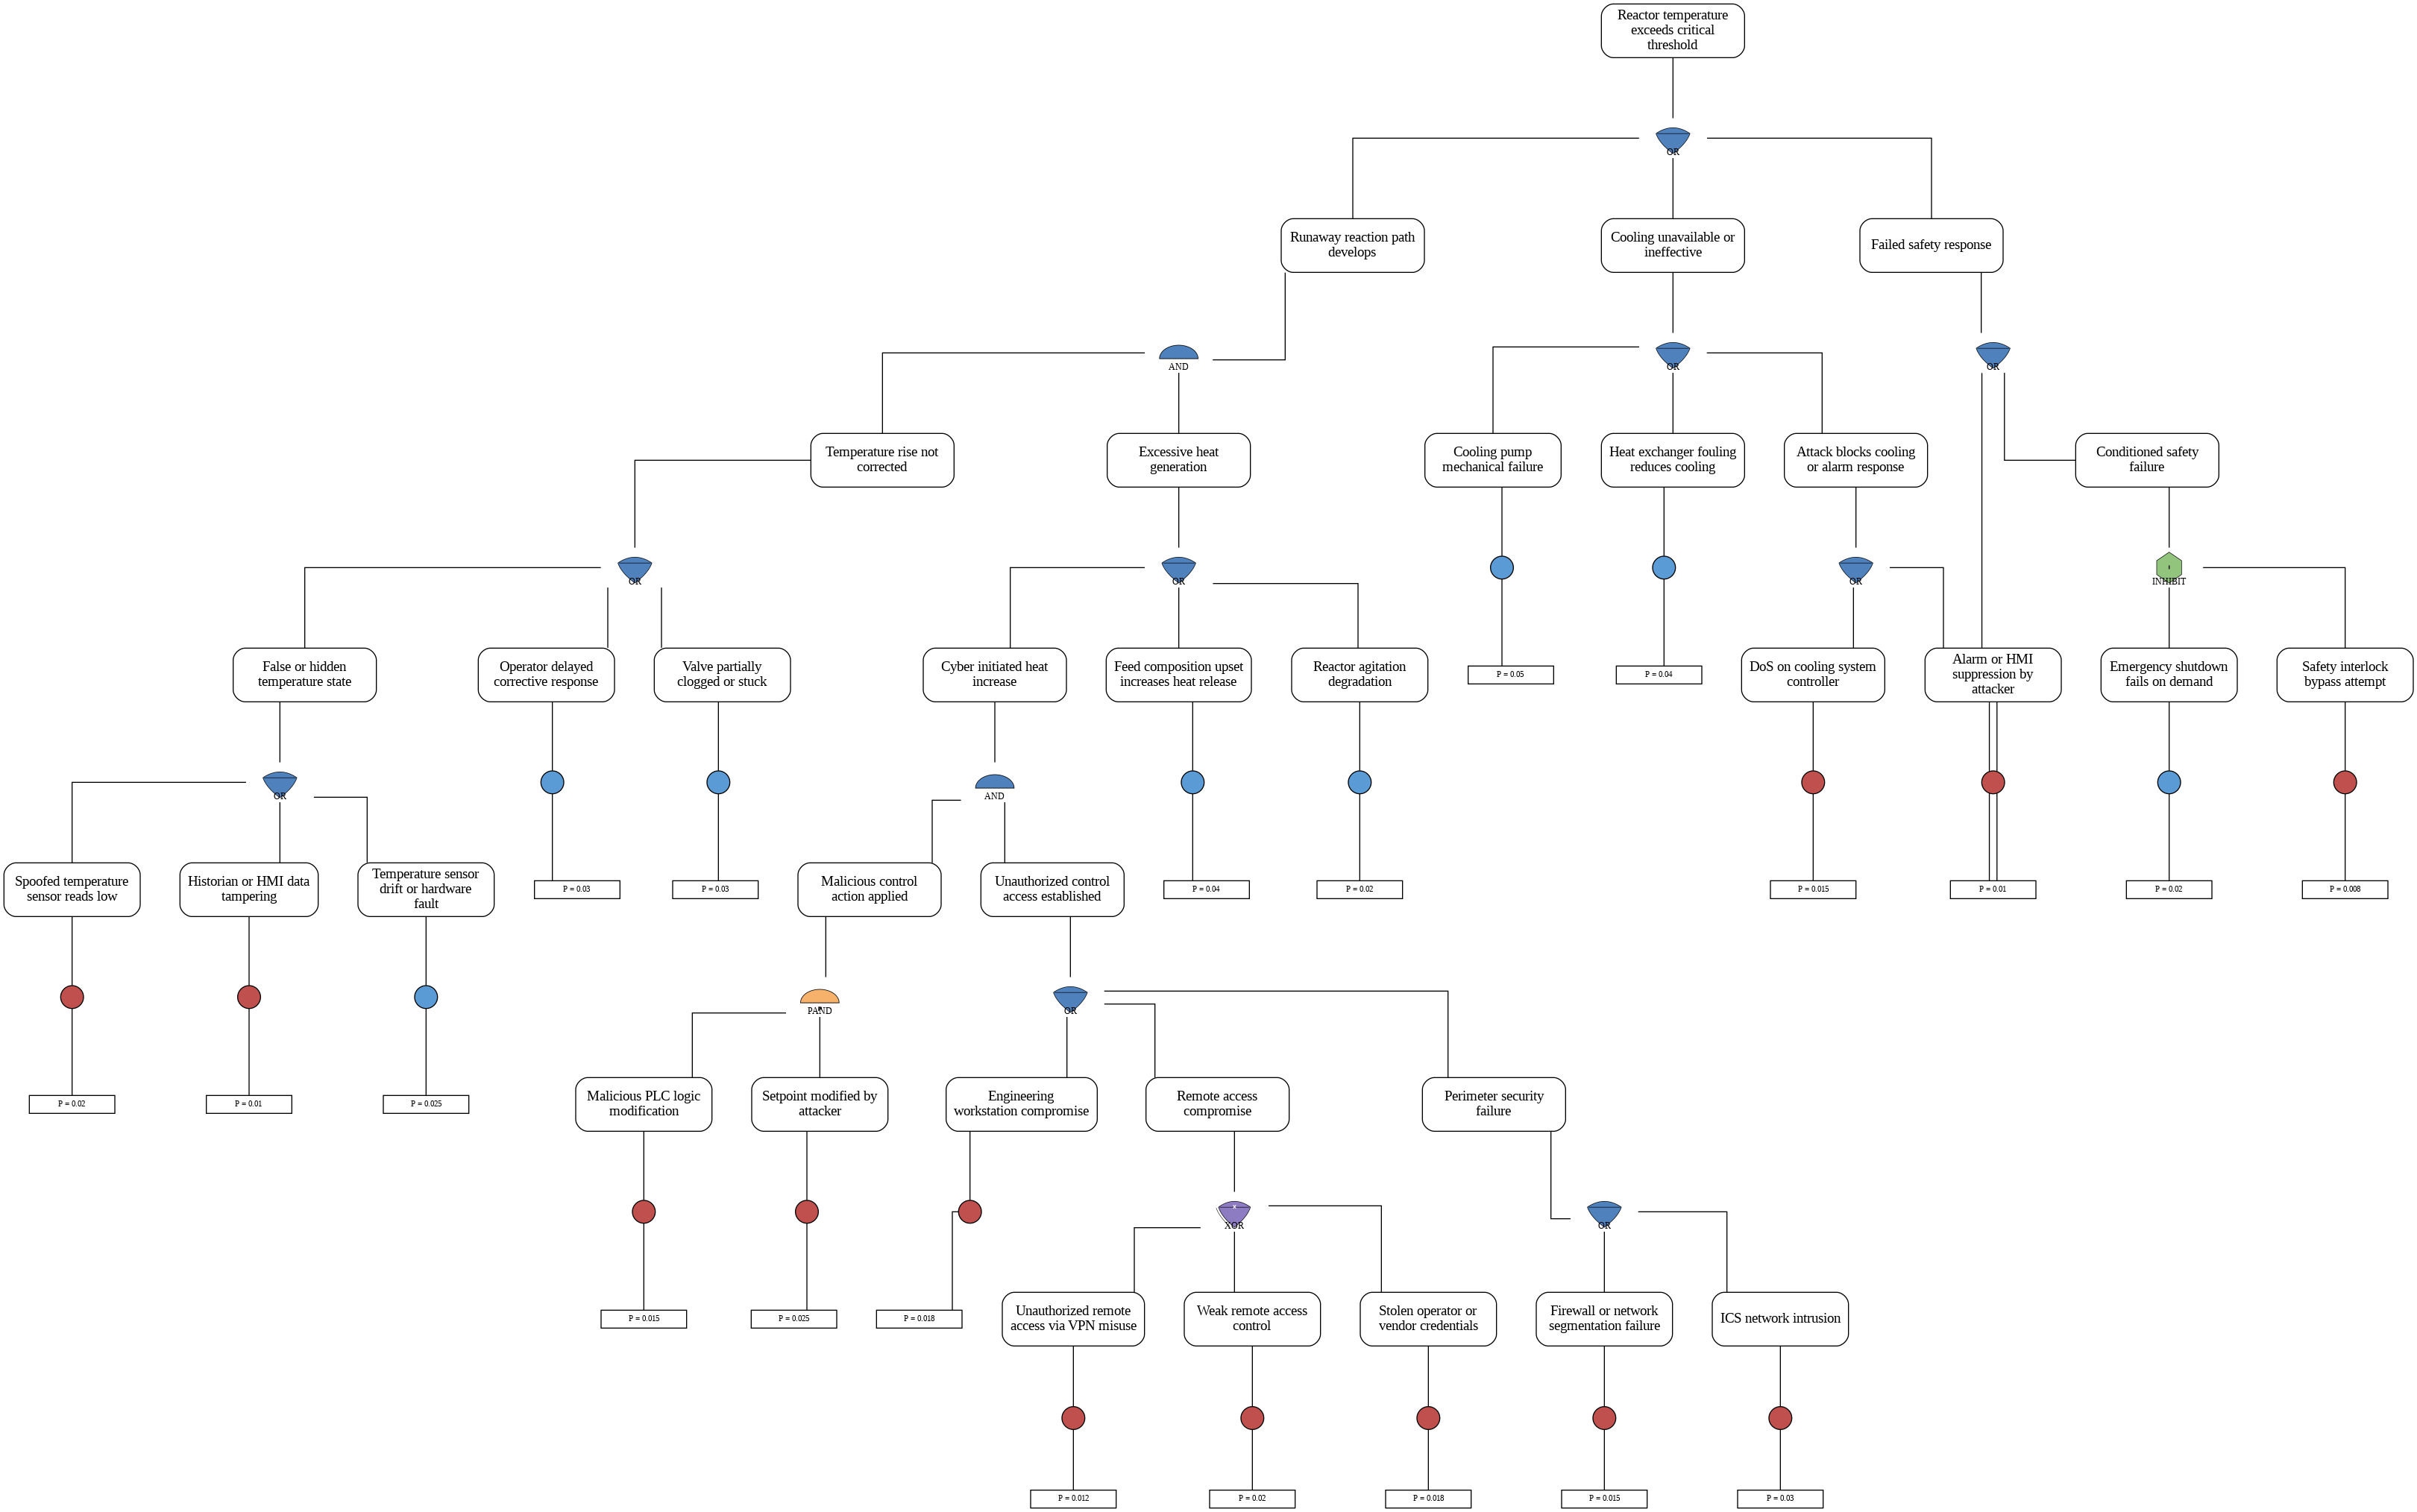

Diagram saved as: extended_chemical_plant_fault_tree.png
MOCUS and MICSUP match: True


,ID,Cut Set,Order
0,1,Alarm or HMI suppression by attacker,1
1,2,Cooling pump mechanical failure,1
2,3,DoS on cooling system controller,1
3,4,Heat exchanger fouling reduces cooling,1
4,5,"Emergency shutdown fails on demand, Safety int...",2
5,6,"Feed composition upset increases heat release,...",2
6,7,"Feed composition upset increases heat release,...",2
7,8,"Feed composition upset increases heat release,...",2
8,9,"Feed composition upset increases heat release,...",2
9,10,"Feed composition upset increases heat release,...",2


In [17]:
from __future__ import annotations  # allows forward references in type hints

from dataclasses import dataclass, field  # for compact class definitions
from itertools import product  # used in MICSUP cartesian combinations
from typing import Dict, List, Optional, Set, Tuple  # type annotations
import os  # file and directory operations
import tempfile  # temporary folder creation

import pandas as pd  # table generation
import matplotlib.pyplot as plt  # drawing gate icons
from matplotlib.patches import Wedge, PathPatch  # custom shapes for icons
from matplotlib.path import Path  # custom curved paths
from graphviz import Digraph  # fault tree diagram generation
from IPython.display import Image, display  # notebook image display


# BLOCK 1: AUTO-GENERATE GATE ICONS

def create_gate_icons(output_dir: str) -> Dict[str, str]:
    """
    Create PNG icons for supported gates.
    Returns a dictionary of gate type -> file path.
    """
    os.makedirs(output_dir, exist_ok=True)  # create output folder if missing

    paths = {
        "AND": os.path.join(output_dir, "and_gate.png"),
        "OR": os.path.join(output_dir, "or_gate.png"),
        "XOR": os.path.join(output_dir, "xor_gate.png"),
        "PAND": os.path.join(output_dir, "pand_gate.png"),
        "INHIBIT": os.path.join(output_dir, "inhibit_gate.png"),
    }

    # AND gate icon
    fig, ax = plt.subplots(figsize=(2, 1.4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")  # hide axes

    wedge = Wedge(
        (0.5, 0.35),
        r=0.35,
        theta1=0,
        theta2=180,
        facecolor="#4F81BD",
        edgecolor="black",
        linewidth=1.2
    )
    ax.add_patch(wedge)
    ax.plot([0.15, 0.85], [0.35, 0.35], color="black", linewidth=1.2)
    plt.savefig(paths["AND"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # OR gate icon
    fig, ax = plt.subplots(figsize=(2, 1.6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    verts = [
        (0.15, 0.62),
        (0.50, 0.92),
        (0.85, 0.62),
        (0.78, 0.36),
        (0.50, 0.10),
        (0.22, 0.36),
        (0.15, 0.62),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.CURVE3,
        Path.CURVE3,
        Path.CURVE3,
        Path.CURVE3,
    ]
    patch = PathPatch(Path(verts, codes), facecolor="#4F81BD", edgecolor="black", linewidth=1.2)
    ax.add_patch(patch)
    ax.plot([0.18, 0.82], [0.62, 0.62], color="black", linewidth=1.2)
    plt.savefig(paths["OR"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # XOR gate icon
    fig, ax = plt.subplots(figsize=(2, 1.7))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    patch = PathPatch(Path(verts, codes), facecolor="#8E7CC3", edgecolor="black", linewidth=1.2)
    ax.add_patch(patch)
    ax.plot([0.18, 0.82], [0.62, 0.62], color="black", linewidth=1.2)

    extra_verts = [
        (0.10, 0.60),
        (0.17, 0.36),
        (0.40, 0.12),
    ]
    extra_codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3]
    extra_patch = PathPatch(Path(extra_verts, extra_codes), facecolor="none", edgecolor="black", linewidth=1.0)
    ax.add_patch(extra_patch)

    ax.text(0.5, 0.62, "X", ha="center", va="center", fontsize=12, color="white", weight="bold")
    plt.savefig(paths["XOR"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # PAND gate icon
    fig, ax = plt.subplots(figsize=(2, 1.4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    wedge = Wedge(
        (0.5, 0.35),
        r=0.35,
        theta1=0,
        theta2=180,
        facecolor="#F6B26B",
        edgecolor="black",
        linewidth=1.2
    )
    ax.add_patch(wedge)
    ax.plot([0.15, 0.85], [0.35, 0.35], color="black", linewidth=1.2)
    ax.text(0.5, 0.18, "P", ha="center", va="center", fontsize=12, color="black", weight="bold")
    plt.savefig(paths["PAND"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    # INHIBIT gate icon
    fig, ax = plt.subplots(figsize=(1.6, 1.6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    inhibit_shape = plt.Polygon(
        [[0.50, 0.90], [0.82, 0.68], [0.82, 0.32], [0.50, 0.10], [0.18, 0.32], [0.18, 0.68]],
        closed=True,
        facecolor="#93C47D",
        edgecolor="black",
        linewidth=1.2
    )
    ax.add_patch(inhibit_shape)
    ax.text(0.5, 0.5, "I", ha="center", va="center", fontsize=12, color="black", weight="bold")
    plt.savefig(paths["INHIBIT"], dpi=300, transparent=True, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    return paths  # return icon file paths


# BLOCK 2: NODE DEFINITION

@dataclass
class FaultTreeNode:
    """
    Represents one node in a fault tree.
    Supported node types:
    BASIC, AND, OR, XOR, PAND, INHIBIT
    """
    name: str
    node_type: str
    probability: Optional[float] = None
    children: List["FaultTreeNode"] = field(default_factory=list)

    def is_basic(self) -> bool:
        return self.node_type == "BASIC"  # check whether node is a basic event

    def validate(self) -> None:
        valid_types = {"BASIC", "AND", "OR", "XOR", "PAND", "INHIBIT"}

        if self.node_type not in valid_types:
            raise ValueError(f"Invalid node type '{self.node_type}' in node '{self.name}'.")

        if self.is_basic():
            if self.probability is None:
                raise ValueError(f"Basic event '{self.name}' must have a probability.")
            if not (0.0 <= self.probability <= 1.0):
                raise ValueError(f"Probability of '{self.name}' must be between 0 and 1.")
            if self.children:
                raise ValueError(f"Basic event '{self.name}' cannot have children.")
        else:
            if self.probability is not None:
                raise ValueError(f"Gate node '{self.name}' must not have a direct probability.")
            if not self.children:
                raise ValueError(f"Gate node '{self.name}' must have at least one child.")

            if self.node_type == "INHIBIT" and len(self.children) != 2:
                raise ValueError(f"INHIBIT gate '{self.name}' must have exactly 2 children.")

            if self.node_type == "PAND" and len(self.children) < 2:
                raise ValueError(f"PAND gate '{self.name}' must have at least 2 children.")

            if self.node_type == "XOR" and len(self.children) < 2:
                raise ValueError(f"XOR gate '{self.name}' must have at least 2 children.")


# BLOCK 3: UTILITY FUNCTIONS

def and_gate_probability(probabilities: List[float]) -> float:
    result = 1.0
    for p in probabilities:
        result *= p  # AND = product of all probabilities
    return result


def or_gate_probability(probabilities: List[float]) -> float:
    result = 1.0
    for p in probabilities:
        result *= (1.0 - p)  # product of non-occurrence
    return 1.0 - result  # OR = 1 - product of non-occurrence


def xor_gate_probability(probabilities: List[float]) -> float:
    """
    Probability that exactly one child event occurs.
    """
    total = 0.0
    for i, p in enumerate(probabilities):
        term = p
        for j, q in enumerate(probabilities):
            if i != j:
                term *= (1.0 - q)  # all others must not occur
        total += term
    return total


def pand_gate_probability(probabilities: List[float]) -> float:
    """
    Static approximation for Priority AND.
    Since dynamic timing/order is not modeled here,
    PAND is approximated as AND.
    """
    return and_gate_probability(probabilities)


def inhibit_gate_probability(probabilities: List[float]) -> float:
    """
    INHIBIT gate is modeled as:
    output = main event AND condition event
    """
    if len(probabilities) != 2:
        raise ValueError("INHIBIT gate requires exactly 2 child probabilities.")
    return probabilities[0] * probabilities[1]


def minimize_cut_sets(cut_sets: List[Set[str]]) -> List[Set[str]]:
    unique_sets = list({frozenset(cs) for cs in cut_sets})  # remove duplicates
    unique_sets.sort(key=lambda s: (len(s), sorted(s)))  # sort by size

    minimal: List[frozenset] = []
    for candidate in unique_sets:
        is_superset = False
        for kept in minimal:
            if kept.issubset(candidate):  # skip non-minimal supersets
                is_superset = True
                break
        if not is_superset:
            minimal.append(candidate)

    return [set(x) for x in minimal]


def wrap_text(text: str, max_len: int = 22, max_lines: int = 4) -> str:
    words = text.split()
    lines = []
    current = ""

    for word in words:
        candidate = f"{current} {word}".strip()
        if len(candidate) <= max_len:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = word

    if current:
        lines.append(current)

    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1][:max(0, max_len - 3)] + "..."  # truncate long labels

    return "\n".join(lines)


def format_prob(p: float, decimals: int = 3) -> str:
    return f"{round(p, decimals):g}"  # clean probability formatting


def is_security_event(name: str) -> bool:
    keywords = [
        "intrusion", "attacker", "spoofed", "dos", "alarm",
        "vpn", "historian", "malicious", "credential",
        "workstation", "hmi", "interlock", "remote access",
        "firewall", "segmentation", "logic"
    ]
    lower_name = name.lower()  # case-insensitive matching
    return any(k in lower_name for k in keywords)  # detect cyber-related events


# BLOCK 4: MAIN FAULT TREE CLASS

class FaultTree:
    """
    Main Fault Tree class supporting:
    - validation
    - probability analysis
    - results tables
    - MOCUS
    - MICSUP
    - visualization
    """

    def __init__(self, root: FaultTreeNode, title: str = "Fault Tree") -> None:
        self.root = root  # top event node
        self.title = title  # tree title
        self._validate_tree()  # validate structure at initialization

    # VALIDATION / TRAVERSAL

    def _validate_tree(self) -> None:
        visited = set()  # track visited nodes

        def dfs(node: FaultTreeNode) -> None:
            if id(node) in visited:
                return
            visited.add(id(node))
            node.validate()  # validate current node
            for child in node.children:
                dfs(child)  # recursively validate children

        dfs(self.root)

    def _collect_nodes(self) -> List[FaultTreeNode]:
        nodes: List[FaultTreeNode] = []

        def dfs(node: FaultTreeNode) -> None:
            nodes.append(node)  # collect node into list
            for child in node.children:
                dfs(child)

        dfs(self.root)
        return nodes

    def build_lookup(self) -> Dict[str, FaultTreeNode]:
        lookup: Dict[str, FaultTreeNode] = {}

        def dfs(node: FaultTreeNode) -> None:
            lookup[node.name] = node  # map node name to node object
            for child in node.children:
                dfs(child)

        dfs(self.root)
        return lookup

    # PROBABILITY ANALYSIS

    def evaluate_probabilities(self, verbose: bool = False) -> Tuple[float, Dict[str, float]]:
        results: Dict[str, float] = {}  # store probability of each node

        def evaluate(node: FaultTreeNode) -> float:
            if node.is_basic():
                results[node.name] = node.probability
                if verbose:
                    print(f"[BASIC] {node.name}")
                    print(f"        P = {format_prob(node.probability)}")
                return node.probability

            child_probabilities = [evaluate(child) for child in node.children]  # recursive evaluation

            if node.node_type == "AND":
                value = and_gate_probability(child_probabilities)
            elif node.node_type == "OR":
                value = or_gate_probability(child_probabilities)
            elif node.node_type == "XOR":
                value = xor_gate_probability(child_probabilities)
            elif node.node_type == "PAND":
                value = pand_gate_probability(child_probabilities)
            elif node.node_type == "INHIBIT":
                value = inhibit_gate_probability(child_probabilities)
            else:
                raise ValueError(f"Unknown node type: {node.node_type}")

            results[node.name] = value  # store computed gate probability

            if verbose:
                print(f"[{node.node_type}] {node.name}")
                for child, prob in zip(node.children, child_probabilities):
                    print(f"        Child: {child.name} -> {format_prob(prob)}")
                print(f"        Result: P({node.name}) = {format_prob(value)}")

            return value

        top_probability = evaluate(self.root)  # evaluate from top event
        return top_probability, results

    def probability_table(self) -> pd.DataFrame:
        _, probabilities = self.evaluate_probabilities(verbose=False)
        rows = []

        for node in self._collect_nodes():
            rows.append({
                "Node": node.name,
                "Type": node.node_type,
                "Probability": format_prob(probabilities[node.name])  # formatted probability per node
            })

        df = pd.DataFrame(rows)
        type_order = {"BASIC": 0, "AND": 1, "OR": 2, "XOR": 3, "PAND": 4, "INHIBIT": 5}
        df["SortKey"] = df["Type"].map(type_order)  # sort by node type
        df = df.sort_values(["SortKey", "Node"]).drop(columns=["SortKey"]).reset_index(drop=True)
        return df

    def gate_analysis_table(self) -> pd.DataFrame:
        _, probabilities = self.evaluate_probabilities(verbose=False)
        rows = []

        def dfs(node: FaultTreeNode) -> None:
            if not node.is_basic():
                child_names = [child.name for child in node.children]
                child_probs = [probabilities[child.name] for child in node.children]

                rows.append({
                    "Gate": node.name,
                    "Gate Type": node.node_type,
                    "Children": " | ".join(child_names),
                    "Child Probabilities": " | ".join(format_prob(p) for p in child_probs),
                    "Gate Probability": format_prob(probabilities[node.name])  # output of gate
                })

            for child in node.children:
                dfs(child)

        dfs(self.root)
        return pd.DataFrame(rows)

    # MOCUS

    def mocus(self) -> Tuple[List[Set[str]], List[Set[str]]]:
        """
        Structural cut-set generation.
        OR and XOR expand like separate rows.
        AND, PAND, INHIBIT expand like combined rows.
        """
        lookup = self.build_lookup()
        rows: List[List[str]] = [[self.root.name]]  # start from top event

        changed = True
        while changed:
            changed = False
            new_rows: List[List[str]] = []

            for row in rows:
                expanded = False

                for index, event_name in enumerate(row):
                    node = lookup[event_name]

                    if node.is_basic():
                        continue  # basic events are final

                    expanded = True
                    changed = True

                    if node.node_type in {"OR", "XOR"}:
                        for child in node.children:
                            new_rows.append(row[:index] + [child.name] + row[index + 1:])  # separate expansion

                    elif node.node_type in {"AND", "PAND", "INHIBIT"}:
                        child_names = [child.name for child in node.children]
                        new_rows.append(row[:index] + child_names + row[index + 1:])  # combined expansion

                    else:
                        raise ValueError(f"Unknown node type in MOCUS: {node.node_type}")

                    break

                if not expanded:
                    new_rows.append(row)

            rows = new_rows

        all_cut_sets = [set(row) for row in rows]
        minimal_cut_sets = minimize_cut_sets(all_cut_sets)  # remove supersets
        return all_cut_sets, minimal_cut_sets

    # MICSUP

    def micsup(self) -> List[Set[str]]:
        """
        Structural bottom-up minimal cut set generation.
        OR and XOR -> union
        AND, PAND, INHIBIT -> cartesian product
        """
        def compute(node: FaultTreeNode) -> List[Set[str]]:
            if node.is_basic():
                return [{node.name}]  # basic event itself is a cut set

            child_cut_sets = [compute(child) for child in node.children]

            if node.node_type in {"OR", "XOR"}:
                combined: List[Set[str]] = []
                for csets in child_cut_sets:
                    combined.extend(csets)  # OR/XOR union of child cut sets
                return minimize_cut_sets(combined)

            if node.node_type in {"AND", "PAND", "INHIBIT"}:
                combined: List[Set[str]] = []
                for combo in product(*child_cut_sets):
                    merged: Set[str] = set()
                    for cs in combo:
                        merged |= cs  # merge each combination
                    combined.append(merged)
                return minimize_cut_sets(combined)

            raise ValueError(f"Unknown node type in MICSUP: {node.node_type}")

        return compute(self.root)

    def cut_set_table(self, cut_sets: List[Set[str]]) -> pd.DataFrame:
        rows = []
        for idx, cut_set in enumerate(cut_sets, start=1):
            rows.append({
                "ID": idx,
                "Cut Set": ", ".join(sorted(cut_set)),
                "Order": len(cut_set)  # size of cut set
            })

        if not rows:
            return pd.DataFrame(columns=["ID", "Cut Set", "Order"])

        df = pd.DataFrame(rows)
        df = df.sort_values(["Order", "Cut Set"]).reset_index(drop=True)
        return df

    # VISUALIZATION

    def visualize_standard_fta(self, save_path: Optional[str] = None) -> str:
        output_name = save_path if save_path else "extended_fault_tree"

        temp_dir = tempfile.mkdtemp(prefix="fta_icons_")
        gate_icons = create_gate_icons(temp_dir)  # create gate icon images

        dot = Digraph("FaultTree", format="png")
        dot.attr(rankdir="TB", splines="ortho", nodesep="0.55", ranksep="0.85")  # top-down tree layout
        dot.attr(fontname="Helvetica")
        dot.attr("edge", fontname="Helvetica", fontsize="8")

        node_ids: Dict[str, str] = {}
        counter = 0

        def get_node_id(node_name: str) -> str:
            nonlocal counter
            if node_name not in node_ids:
                node_ids[node_name] = f"n{counter}"  # unique graph node id
                counter += 1
            return node_ids[node_name]

        def add_node_recursive(node: FaultTreeNode) -> str:
            base_id = get_node_id(node.name)

            # BASIC event
            if node.node_type == "BASIC":
                event_id = f"{base_id}_event"
                symbol_id = f"{base_id}_symbol"
                prob_id = f"{base_id}_prob"

                dot.node(
                    event_id,
                    label=wrap_text(node.name),  # event label
                    shape="box",
                    style="rounded,filled",
                    fillcolor="white",
                    color="black",
                    width="1.9",
                    height="0.75"
                )

                basic_fill = "#C0504D" if is_security_event(node.name) else "#5B9BD5"  # cyber vs normal event color
                dot.node(
                    symbol_id,
                    label="",
                    shape="circle",
                    style="filled",
                    fillcolor=basic_fill,
                    color="black",
                    width="0.32",
                    height="0.32",
                    fixedsize="true"
                )

                dot.node(
                    prob_id,
                    label=f"P = {format_prob(node.probability)}",  # show probability below event
                    shape="box",
                    style="filled",
                    fillcolor="white",
                    color="black",
                    width="1.2",
                    height="0.25",
                    fontsize="8"
                )

                dot.edge(event_id, symbol_id, arrowhead="none")
                dot.edge(symbol_id, prob_id, arrowhead="none")
                return event_id

            # GATE node
            event_id = f"{base_id}_event"
            gate_id = f"{base_id}_gate"

            dot.node(
                event_id,
                label=wrap_text(node.name),  # gate output label
                shape="box",
                style="rounded,filled",
                fillcolor="white",
                color="black",
                width="2.0",
                height="0.75"
            )

            gate_image = gate_icons[node.node_type]

            dot.node(
                gate_id,
                label=node.node_type,
                labelloc="b",
                shape="none",
                image=gate_image,  # gate symbol image
                imagescale="true",
                width="0.95",
                height="0.55",
                fixedsize="true",
                fontsize="9"
            )

            dot.edge(event_id, gate_id, arrowhead="none")

            for child in node.children:
                child_anchor = add_node_recursive(child)  # recursively add child nodes
                dot.edge(gate_id, child_anchor, arrowhead="none")

            return event_id

        add_node_recursive(self.root)  # start drawing from root

        png_path = dot.render(output_name, cleanup=True)  # generate PNG diagram

        if os.path.exists(png_path):
            display(Image(filename=png_path))  # show diagram in notebook
        else:
            print("Could not find generated image. Please check Graphviz installation.")

        print(f"Diagram saved as: {png_path}")
        return png_path

    def run_dashboard(self, image_path: Optional[str] = None) -> Dict[str, pd.DataFrame]:
        top_probability, _ = self.evaluate_probabilities(verbose=False)  # compute top event probability

        print("=" * 100)
        print(self.title.upper())  # show analysis title
        print("=" * 100)
        print()
        print(f"Top Event Probability: {format_prob(top_probability)}")
        print()

        self.visualize_standard_fta(save_path=image_path)  # display diagram

        probability_df = self.probability_table()  # all node probabilities
        gate_df = self.gate_analysis_table()  # gate-by-gate results

        all_cut_sets_mocus, minimal_mocus = self.mocus()  # MOCUS results
        minimal_micsup = self.micsup()  # MICSUP results

        mocus_all_df = self.cut_set_table(all_cut_sets_mocus)
        mocus_min_df = self.cut_set_table(minimal_mocus)
        micsup_min_df = self.cut_set_table(minimal_micsup)

        mocus_sorted = sorted(tuple(sorted(cs)) for cs in minimal_mocus)
        micsup_sorted = sorted(tuple(sorted(cs)) for cs in minimal_micsup)

        print("MOCUS and MICSUP match:", mocus_sorted == micsup_sorted)  # consistency check

        return {
            "probability_table": probability_df,
            "gate_analysis_table": gate_df,
            "mocus_all_cut_sets": mocus_all_df,
            "mocus_minimal_cut_sets": mocus_min_df,
            "micsup_minimal_cut_sets": micsup_min_df,
        }


def build_complex_chemical_plant_case() -> FaultTree:
    """
    Complex chemical plant case using:
    AND, OR, XOR, PAND, INHIBIT
    """

    # BASIC EVENTS
    weak_remote_access_control = FaultTreeNode("Weak remote access control", "BASIC", 0.02)
    stolen_credentials = FaultTreeNode("Stolen operator or vendor credentials", "BASIC", 0.018)
    vpn_misuse = FaultTreeNode("Unauthorized remote access via VPN misuse", "BASIC", 0.012)
    firewall_segmentation_failure = FaultTreeNode("Firewall or network segmentation failure", "BASIC", 0.015)
    ics_network_intrusion = FaultTreeNode("ICS network intrusion", "BASIC", 0.03)

    engineering_workstation_compromise = FaultTreeNode("Engineering workstation compromise", "BASIC", 0.018)
    setpoint_modification = FaultTreeNode("Setpoint modified by attacker", "BASIC", 0.025)
    malicious_plc_logic = FaultTreeNode("Malicious PLC logic modification", "BASIC", 0.015)
    safety_interlock_bypass = FaultTreeNode("Safety interlock bypass attempt", "BASIC", 0.008)

    spoofed_temp_sensor = FaultTreeNode("Spoofed temperature sensor reads low", "BASIC", 0.02)
    historian_tampering = FaultTreeNode("Historian or HMI data tampering", "BASIC", 0.01)
    alarm_suppression = FaultTreeNode("Alarm or HMI suppression by attacker", "BASIC", 0.01)

    dos_cooling_controller = FaultTreeNode("DoS on cooling system controller", "BASIC", 0.015)

    feed_composition_upset = FaultTreeNode("Feed composition upset increases heat release", "BASIC", 0.04)
    reactor_agitation_degradation = FaultTreeNode("Reactor agitation degradation", "BASIC", 0.02)
    cooling_pump_failure = FaultTreeNode("Cooling pump mechanical failure", "BASIC", 0.05)
    heat_exchanger_fouling = FaultTreeNode("Heat exchanger fouling reduces cooling", "BASIC", 0.04)
    valve_partially_clogged = FaultTreeNode("Valve partially clogged or stuck", "BASIC", 0.03)
    temp_sensor_drift = FaultTreeNode("Temperature sensor drift or hardware fault", "BASIC", 0.025)
    operator_delay = FaultTreeNode("Operator delayed corrective response", "BASIC", 0.03)
    emergency_shutdown_failure = FaultTreeNode("Emergency shutdown fails on demand", "BASIC", 0.02)

    # NEW GATES
    remote_access_compromise = FaultTreeNode(
        "Remote access compromise",
        "XOR",
        children=[weak_remote_access_control, stolen_credentials, vpn_misuse]
    )

    perimeter_security_failure = FaultTreeNode(
        "Perimeter security failure",
        "OR",
        children=[firewall_segmentation_failure, ics_network_intrusion]
    )

    unauthorized_control_access = FaultTreeNode(
        "Unauthorized control access established",
        "OR",
        children=[remote_access_compromise, perimeter_security_failure, engineering_workstation_compromise]
    )

    malicious_control_action = FaultTreeNode(
        "Malicious control action applied",
        "PAND",
        children=[setpoint_modification, malicious_plc_logic]
    )

    cyber_initiated_heat_increase = FaultTreeNode(
        "Cyber initiated heat increase",
        "AND",
        children=[unauthorized_control_access, malicious_control_action]
    )

    hidden_or_false_temperature_state = FaultTreeNode(
        "False or hidden temperature state",
        "OR",
        children=[spoofed_temp_sensor, historian_tampering, temp_sensor_drift]
    )

    attack_blocks_cooling_or_alarm_response = FaultTreeNode(
        "Attack blocks cooling or alarm response",
        "OR",
        children=[dos_cooling_controller, alarm_suppression]
    )

    excessive_heat_generation = FaultTreeNode(
        "Excessive heat generation",
        "OR",
        children=[cyber_initiated_heat_increase, feed_composition_upset, reactor_agitation_degradation]
    )

    temperature_rise_not_corrected = FaultTreeNode(
        "Temperature rise not corrected",
        "OR",
        children=[hidden_or_false_temperature_state, operator_delay, valve_partially_clogged]
    )

    runaway_reaction_path = FaultTreeNode(
        "Runaway reaction path develops",
        "AND",
        children=[excessive_heat_generation, temperature_rise_not_corrected]
    )

    cooling_unavailable_or_ineffective = FaultTreeNode(
        "Cooling unavailable or ineffective",
        "OR",
        children=[attack_blocks_cooling_or_alarm_response, cooling_pump_failure, heat_exchanger_fouling]
    )

    conditioned_safety_failure = FaultTreeNode(
        "Conditioned safety failure",
        "INHIBIT",
        children=[emergency_shutdown_failure, safety_interlock_bypass]
    )

    failed_safety_response = FaultTreeNode(
        "Failed safety response",
        "OR",
        children=[alarm_suppression, conditioned_safety_failure]
    )

    top_event = FaultTreeNode(
        "Reactor temperature exceeds critical threshold",
        "OR",
        children=[
            runaway_reaction_path,
            cooling_unavailable_or_ineffective,
            failed_safety_response
        ]
    )

    return FaultTree(
        root=top_event,  # set top event as root
        title="Enhanced Industrial Chemical Plant - Security-Informed Safety Fault Tree with Extended Gates"
    )


# EXAMPLE USAGE

plant_tree = build_complex_chemical_plant_case()  # build case study tree
results = plant_tree.run_dashboard(image_path="extended_chemical_plant_fault_tree")  # run full analysis

results["probability_table"]  # node probability table
results["gate_analysis_table"]  # gate-wise analysis table
results["mocus_minimal_cut_sets"]  # minimal cut sets from MOCUS
results["micsup_minimal_cut_sets"]  # minimal cut sets from MICSUP